In [1]:
import cv2
import torch
import numpy as np
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models


In [2]:
# Carregando o modelo
model_inference = models.resnet101(pretrained=False)
num_features = model_inference.fc.in_features
model_inference.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, 2)
)

model_weights_inference = "/home/jovyan/result-ignite-resnet101-test3/best_model_19_accuracy=0.9231.pt"
model_inference.load_state_dict(torch.load(model_weights_inference))

device = "cpu"
model_inference = model_inference.to(device)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


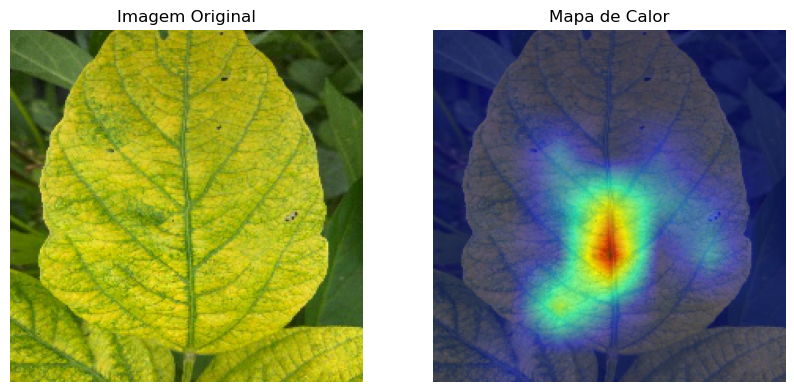

In [8]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_path = 'images/leaf_diseases_750.jpg'
img = Image.open(img_path)
img_tensor = transform(img).unsqueeze(0)  #.to(device)  # Adiciona um batch dimension

# Variável para armazenar as ativações da última camada convolucional
# Variáveis globais para armazenar as ativações e gradientes
activations = None
gradients = None

# 3. Função para capturar as ativações
def save_activation(module, input, output):
    global activations
    activations = output

# Função para capturar os gradientes
def save_gradient(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]  # Captura o primeiro elemento da tuple de gradientes

# Registrar o hook na última camada convolucional
layer = model_inference.layer4[-1]
hook_handle_activations = layer.register_forward_hook(save_activation)
hook_handle_gradients = layer.register_backward_hook(save_gradient)

# Passar a imagem pelo modelo
output = model_inference(img_tensor)
output_idx = output.argmax(dim=1).item()  # Índice da classe predita
score = output[:, output_idx]  # Score da classe predita

# Backward pass para calcular os gradientes
model_inference.zero_grad()
score.backward()

# Remover os hooks após o uso
hook_handle_activations.remove()
hook_handle_gradients.remove()

# 4. Gerar o Heatmap
grads = gradients.detach().cpu().numpy()
activations = activations.detach().cpu().numpy()[0]

weights = np.mean(grads, axis=(1, 2))  # Média dos gradientes
heatmap = np.zeros(activations.shape[1:], dtype=np.float32)


for i, w in enumerate(weights):
    heatmap += w * activations[i]

heatmap = np.maximum(heatmap, 0)  # ReLU
heatmap /= np.max(heatmap)  # Normalizar

# 8. Sobrepor o Heatmap à Imagem Original
heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

img_bgr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)  # Converter para BGR para OpenCV
superimposed_img = cv2.addWeighted(heatmap, 0.6, img_bgr, 0.4, 0)

# 9. Plotar a Imagem Original e o Heatmap Sobreposto Lado a Lado
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Exibir a imagem original
axs[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))  # Converter de volta para RGB
axs[0].axis('off')
axs[0].set_title('Imagem Original')

# Exibir a imagem com o heatmap sobreposto
axs[1].imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))  # Converter de volta para RGB
axs[1].axis('off')
axs[1].set_title('Mapa de Calor')

plt.show()